In [13]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy

import config as CFG
from models import CLIPModel, CLIPModel_ViT, CLIPModel_ViT_L, CLIPModel_CLIP, CLIPModel_resnet152, CLIPModel_resnet101
from dataset import CLIPDataset
import scanpy as sc
from torch.utils.data import DataLoader

import os
import numpy as np
import scanpy as sc

In [14]:
import os
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
# 假设你的 CLIPDataset 和 CLIPModel 已经正确 import

def build_loaders_inference():
    print("Building loaders for all 4 slices...")
    # 🚨 注意：这里强制加上 is_train=False，防止测试集图片被随机翻转！
    
    dataset1 = CLIPDataset(image_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/images/GEX_C73_A1_Merged.tif",
                spatial_pos_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/data/tissue_pos_matrices/tissue_positions_list_1.csv",
                reduced_mtx_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/1/harmony_matrix.npy",
                barcode_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/1/barcodes.tsv",
                is_train=False)
    
    dataset2 = CLIPDataset(image_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/images/GEX_C73_B1_Merged.tif",
                spatial_pos_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/data/tissue_pos_matrices/tissue_positions_list_2.csv",
                reduced_mtx_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/2/harmony_matrix.npy",
                barcode_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/2/barcodes.tsv",
                is_train=False)
    
    dataset3 = CLIPDataset(image_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/images/GEX_C73_C1_Merged.tif",
                spatial_pos_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/data/tissue_pos_matrices/tissue_positions_list_3.csv",
                reduced_mtx_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/3/harmony_matrix.npy",
                barcode_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/3/barcodes.tsv",
                is_train=False)
    
    dataset4 = CLIPDataset(image_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/images/GEX_C73_D1_Merged.tif",
                spatial_pos_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/data/tissue_pos_matrices/tissue_positions_list_4.csv",
                reduced_mtx_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/4/harmony_matrix.npy",
                barcode_path = "/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/4/barcodes.tsv",
                is_train=False)
    
    # 把 1, 2, 3, 4 全部拼在一起
    dataset = torch.utils.data.ConcatDataset([dataset1, dataset2, dataset3, dataset4])
    
    # 返回单一的 DataLoader，这样 tqdm(test_loader) 就不会报错了
    test_loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True, drop_last=False)

    print("Finished building loaders")
    return test_loader


def load_trained_model(model_path, model):
    """单独拿出一个函数来加载权重，避免重复加载"""
    state_dict = torch.load(model_path, map_location="cuda")
    new_state_dict = {}
    for key in state_dict.keys():
        new_key = key.replace('module.', '')  # 去除 DDP 留下的 module. 前缀
        new_key = new_key.replace('well', 'spot') 
        new_state_dict[new_key] = state_dict[key]

    model.load_state_dict(new_state_dict)
    model.cuda()
    model.eval()
    print("Finished loading model weights.")
    return model


def extract_embeddings(model, dataloader):
    """一次性将图像特征和基因特征全部提出来"""
    image_embeddings = []
    spot_embeddings = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting embeddings"):
            # 提取图像潜向量 (256维)
            img_feats = model.image_encoder(batch["image"].cuda())
            img_embeds = model.image_projection(img_feats)
            image_embeddings.append(img_embeds.cpu())
            
            # 提取基因表达潜向量 (256维)
            spot_embeds = model.spot_projection(batch["reduced_expression"].cuda())
            spot_embeddings.append(spot_embeds.cpu())
            
    return torch.cat(image_embeddings), torch.cat(spot_embeddings)


def find_matches(spot_embeddings, query_embeddings, top_k=50):
    """
    K-NN 检索：计算 Query 和 Reference 之间的余弦相似度
    注意：在 BLEEP 论文中，K 近邻的默认值通常是 50
    """
    # 🚨 修复：把 NumPy 数组转换为 PyTorch Tensor，并确保是 float32 类型
    query_tensor = torch.tensor(query_embeddings).float()
    spot_tensor = torch.tensor(spot_embeddings).float()
    
    # 然后再送给 F.normalize 算余弦相似度
    query_norm = F.normalize(query_tensor, p=2, dim=-1).cuda()
    spot_norm = F.normalize(spot_tensor, p=2, dim=-1).cuda()
    
    # 矩阵乘法计算相似度：(Query_N, 256) @ (256, Ref_N) -> (Query_N, Ref_N)
    dot_similarity = query_norm @ spot_norm.T
    print(f"Similarity matrix shape: {dot_similarity.shape}")
    
    # 找出每个 Query 图像最相似的 top_k 个 Reference 基因表达
    _, indices = torch.topk(dot_similarity, k=top_k, dim=1)
    
    return indices.cpu().numpy()

In [15]:
# import os
# import torch
# import numpy as np
# from models import CLIPModel
# from modules import ProjectionHead, timm
# from utils import load_model_checkpoint

# # 1. 基础设置
# datasize = [2378, 2349, 2277, 2265]
# model_path = "/root/disk2/runzhi/BLEEP/bleep_baseline_uni/best.pt"
# save_path = "/root/disk2/runzhi/BLEEP/result/embeddings/"
# uni_model_dir = "/root/disk2/runzhi/BLEEP/UNI_Offline_Model"

# USE_SPOT_ENCODER = False  # 与原推理配置保持一致


# def build_uni_image_encoder(model_dir: str) -> torch.nn.Module:
#     """
#     按要求使用 timm 初始化 UNI 底层架构，并从本地离线权重加载参数。
#     """
#     # 1) 严格按你给的配置初始化 UNI backbone（输出特征维度为 1024）
#     uni_backbone = timm.create_model(
#         "vit_large_patch16_224",
#         img_size=224,
#         patch_size=16,
#         init_values=1e-5,
#         num_classes=0,
#         dynamic_img_size=True,
#     )

#     # 2) 从本地绝对路径加载 UNI 预训练权重
#     uni_weight_path = os.path.join(model_dir, "pytorch_model.bin")
#     state_dict = torch.load(uni_weight_path, map_location="cpu")

#     # 兼容部分 checkpoint 里套了一层 state_dict 的写法
#     if isinstance(state_dict, dict) and "state_dict" in state_dict and isinstance(state_dict["state_dict"], dict):
#         state_dict = state_dict["state_dict"]

#     # 兼容 DataParallel 保存的 module. 前缀
#     if any(k.startswith("module.") for k in state_dict.keys()):
#         state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

#     missing, unexpected = uni_backbone.load_state_dict(state_dict, strict=False)
#     print(f"UNI local weights loaded: missing={len(missing)}, unexpected={len(unexpected)}")

#     return uni_backbone


# def load_trained_model(model_path, model):
#     """沿用原 notebook 的 checkpoint 加载逻辑"""
#     load_info = load_model_checkpoint(
#         model=model,
#         checkpoint_path=model_path,
#         map_location="cuda",
#         strict=False,
#         rename_map={"well": "spot", "image_encoder.model.": "image_encoder."},
#     )

#     ckpt_obj = load_info.get("checkpoint_obj", {})
#     ckpt_args = ckpt_obj.get("args", {}) if isinstance(ckpt_obj, dict) else {}
#     if isinstance(ckpt_args, dict) and ("use_spot_encoder" in ckpt_args):
#         ckpt_use_spot_encoder = bool(ckpt_args["use_spot_encoder"])
#         model_use_spot_encoder = bool(getattr(model, "use_spot_encoder", False))
#         if ckpt_use_spot_encoder != model_use_spot_encoder:
#             print(
#                 f"[Warning] checkpoint use_spot_encoder={ckpt_use_spot_encoder}, "
#                 f"but current model use_spot_encoder={model_use_spot_encoder}."
#             )

#     model.cuda()
#     model.eval()
#     print(
#         f"Finished loading model weights. "
#         f"missing={len(load_info['missing_keys'])}, "
#         f"unexpected={len(load_info['unexpected_keys'])}"
#     )
#     return model


# # 2. 实例化原 CLIPModel
# model = CLIPModel(use_spot_encoder=USE_SPOT_ENCODER).cuda()

# # 3. 强制替换 image_encoder 为 UNI（本地离线权重）
# model.image_encoder = build_uni_image_encoder(uni_model_dir).cuda()

# # 4. 维度对齐：UNI 输出 1024 维，所以 image_projection 改成 1024 -> 256
# model.image_projection = ProjectionHead(embedding_dim=1024, projection_dim=256).cuda()

# # 5. 加载训练好的 BLEEP checkpoint
# model = load_trained_model(model_path, model)

# # 6. 构建 DataLoader
# test_loader = build_loaders_inference()

# # 7. 一次性提取所有图像和基因特征
# img_embeddings_all, spot_embeddings_all = extract_embeddings(model, test_loader)

# # 8. 转成 numpy
# img_embeddings_all = img_embeddings_all.numpy()
# spot_embeddings_all = spot_embeddings_all.numpy()

# print(f"总 Image 特征维度: {img_embeddings_all.shape}")
# print(f"总 Spot 特征维度: {spot_embeddings_all.shape}")

# # 9. 按照 datasize 切片并保存
# if not os.path.exists(save_path):
#     os.makedirs(save_path)

# for i in range(4):
#     index_start = sum(datasize[:i])
#     index_end = sum(datasize[:i+1])

#     image_embeddings = img_embeddings_all[index_start:index_end]
#     spot_embeddings = spot_embeddings_all[index_start:index_end]

#     print(f"切片 {i+1} - img: {image_embeddings.shape}, spot: {spot_embeddings.shape}")

#     np.save(save_path + f"img_embeddings_{i+1}.npy", image_embeddings.T)
#     np.save(save_path + f"spot_embeddings_{i+1}.npy", spot_embeddings.T)

# print("所有切片特征均已成功保存（UNI 版本）！")

import os
import torch
import numpy as np

# ===== 核心：引入 timm 的模型注册表 =====
from timm.models.registry import register_model
from modules import timm, ProjectionHead
from models import CLIPModel
import models  # 用于合法修改全局配置 CFG
from utils import load_model_checkpoint

# ⚠️ 注意：如果以下两个函数是从其他文件导入的，请取消注释并修改为正确的导入路径
# from your_dataset_file import build_loaders_inference
# from your_engine_file import extract_embeddings


# =========================================================
# 第一步：将 UNI 注册为 timm 的官方模型
# =========================================================
@register_model
def uni(pretrained=False, **kwargs):
    """
    当代码任何地方调用 timm.create_model("uni") 时，都会自动执行这里。
    我们在这里向 timm 声明 UNI 的真实骨架 (ViT-Large)。
    """
    # 过滤掉外界可能传入的冲突参数，强制设为 0 类（用于提取特征）
    kwargs.pop("num_classes", None) 
    
    model = timm.create_model(
        "vit_large_patch16_224",
        img_size=224,
        patch_size=16,
        init_values=1e-5,
        num_classes=0,
        dynamic_img_size=True,
        **kwargs
    )
    return model


# =========================================================
# 辅助函数：加载 BLEEP 检查点
# =========================================================
def load_trained_model(model_path, model):
    """沿用原 notebook 的 checkpoint 加载逻辑"""
    load_info = load_model_checkpoint(
        model=model,
        checkpoint_path=model_path,
        map_location="cuda",
        strict=False,
        rename_map={"well": "spot", "image_encoder.model.": "image_encoder."},
    )

    ckpt_obj = load_info.get("checkpoint_obj", {})
    ckpt_args = ckpt_obj.get("args", {}) if isinstance(ckpt_obj, dict) else {}
    if isinstance(ckpt_args, dict) and ("use_spot_encoder" in ckpt_args):
        ckpt_use_spot_encoder = bool(ckpt_args["use_spot_encoder"])
        model_use_spot_encoder = bool(getattr(model, "use_spot_encoder", False))
        if ckpt_use_spot_encoder != model_use_spot_encoder:
            print(
                f"[Warning] checkpoint use_spot_encoder={ckpt_use_spot_encoder}, "
                f"but current model use_spot_encoder={model_use_spot_encoder}."
            )

    model.cuda()
    model.eval()
    print(
        f"Finished loading model weights. "
        f"missing={len(load_info['missing_keys'])}, "
        f"unexpected={len(load_info['unexpected_keys'])}"
    )
    return model


# =========================================================
# 主程序入口 (必须放在 if __name__ == "__main__": 下方)
# =========================================================
if __name__ == "__main__":
    # 1. 基础设置
    datasize = [2378, 2349, 2277, 2265]
    model_path = "/root/disk2/runzhi/BLEEP/bleep_full_uni_4/best.pt"
    save_path = "/root/disk2/runzhi/BLEEP/result/embeddings/"
    uni_model_dir = "/root/disk2/runzhi/BLEEP/UNI_Offline_Model"
    USE_SPOT_ENCODER = False

    # 2. 光明正大地告诉全局配置：我们用的就是 uni
    models.CFG.model_name = "uni"

    print("正在初始化模型...")
    # 此时 CLIPModel 内部初始化 ImageEncoder 时，会向 timm 索要 "uni"
    # timm 会骄傲地交出我们上面 @register_model 注册的架构
    model = CLIPModel(use_spot_encoder=USE_SPOT_ENCODER).cuda()

    print("加载 UNI 离线预训练权重...")
    # 3. 将 UNI 的灵魂（离线权重）注入到刚建好的骨架中
    uni_weight_path = os.path.join(uni_model_dir, "pytorch_model.bin")
    state_dict = torch.load(uni_weight_path, map_location="cpu")
    
    if isinstance(state_dict, dict) and "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]
    if any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

    # BLEEP 的 ImageEncoder 习惯把 timm 骨架存在 self.image_encoder.model 里
    missing, unexpected = model.image_encoder.model.load_state_dict(state_dict, strict=False)
    print(f"UNI local weights loaded: missing={len(missing)}, unexpected={len(unexpected)}")

    # 4. 维度对齐：UNI 提取的特征是 1024 维，替换默认的投影头 (1024 -> 256)
    model.image_projection = ProjectionHead(embedding_dim=1024, projection_dim=256).cuda()

    print("加载 BLEEP 对齐微调后的检查点...")
    # 5. 加载训练好的 BLEEP 双模态 checkpoint
    model = load_trained_model(model_path, model)

    print("构建 DataLoader...")
    # 6. 构建 DataLoader 
    # ⚠️ 最后的叮嘱：确保 build_loaders_inference 里面把 DataLoader 的 num_workers 改成了 0
    test_loader = build_loaders_inference()

    print("开始提取特征...")
    # 7. 一次性提取所有图像和基因特征
    # ⚠️ 最后的叮嘱：确保 extract_embeddings 函数里面写了 with torch.no_grad():
    img_embeddings_all, spot_embeddings_all = extract_embeddings(model, test_loader)

    print("特征提取完成，正在处理格式...")
    # 8. 安全转为 numpy (防止 CUDA Tensor 直接 numpy() 报错)
    if torch.is_tensor(img_embeddings_all):
        img_embeddings_all = img_embeddings_all.cpu().numpy()
    if torch.is_tensor(spot_embeddings_all):
        spot_embeddings_all = spot_embeddings_all.cpu().numpy()

    print(f"总 Image 特征维度: {img_embeddings_all.shape}")
    print(f"总 Spot 特征维度: {spot_embeddings_all.shape}")

    # 9. 按照 datasize 切片并保存
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    for i in range(4):
        index_start = sum(datasize[:i])
        index_end = sum(datasize[:i+1])

        image_embeddings = img_embeddings_all[index_start:index_end]
        spot_embeddings = spot_embeddings_all[index_start:index_end]

        print(f"正在保存切片 {i+1} - img: {image_embeddings.shape}, spot: {spot_embeddings.shape}")

        np.save(os.path.join(save_path, f"img_embeddings_{i+1}.npy"), image_embeddings.T)
        np.save(os.path.join(save_path, f"spot_embeddings_{i+1}.npy"), spot_embeddings.T)

    print("🎉 所有切片特征均已成功保存！")


/tmp/ipykernel_2983285/2897536336.py:143: UserWarning: Overwriting uni in registry with __main__.uni. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def uni(pretrained=False, **kwargs):


正在初始化模型...
Loaded local weights from /root/disk2/runzhi/BLEEP/model.safetensors (missing=342, unexpected=320).
加载 UNI 离线预训练权重...


/tmp/ipykernel_2983285/2897536336.py:219: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(uni_weight_path, map_location="cpu")


UNI local weights loaded: missing=2, unexpected=2
加载 BLEEP 对齐微调后的检查点...


/root/disk2/runzhi/BLEEP/utils.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_obj = torch.load(checkpoint_path, map_location=map_location)


Finished loading model weights. missing=342, unexpected=342
构建 DataLoader...
Building loaders for all 4 slices...
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished building loaders
开始提取特征...


Extracting embeddings: 100%|██████████| 290/290 [02:00<00:00,  2.40it/s]

特征提取完成，正在处理格式...
总 Image 特征维度: (9269, 256)
总 Spot 特征维度: (9269, 256)
正在保存切片 1 - img: (2378, 256), spot: (2378, 256)
正在保存切片 2 - img: (2349, 256), spot: (2349, 256)
正在保存切片 3 - img: (2277, 256), spot: (2277, 256)
正在保存切片 4 - img: (2265, 256), spot: (2265, 256)
🎉 所有切片特征均已成功保存！


In [16]:

#infer spot embeddings and expression
spot_expression1 = np.load("/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/1/harmony_matrix.npy")
spot_expression2 = np.load("/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/2/harmony_matrix.npy")
spot_expression3 = np.load("/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/3/harmony_matrix.npy")
spot_expression4 = np.load("/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/4/harmony_matrix.npy")

save_path = "/root/disk2/runzhi/BLEEP/result/embeddings/"
spot_embeddings1 = np.load(save_path + "spot_embeddings_1.npy")
spot_embeddings2 = np.load(save_path + "spot_embeddings_2.npy")
spot_embeddings3 = np.load(save_path + "spot_embeddings_3.npy")
spot_embeddings4 = np.load(save_path + "spot_embeddings_4.npy")
image_embeddings3 = np.load(save_path + "img_embeddings_3.npy")


#query
image_query = image_embeddings3
expression_gt = spot_expression3
spot_key = np.concatenate([spot_embeddings1, spot_embeddings2, spot_embeddings4], axis = 1)
expression_key = np.concatenate([spot_expression1, spot_expression2, spot_expression4], axis = 1)



In [17]:
import pandas as pd

method = "average"

save_path = "/root/disk2/runzhi/BLEEP/result/embeddings/"
if image_query.shape[1] != 256:
    image_query = image_query.T
    print("image query shape: ", image_query.shape)
if expression_gt.shape[0] != image_query.shape[0]:
    expression_gt = expression_gt.T
    print("expression_gt shape: ", expression_gt.shape)
if spot_key.shape[1] != 256:
    spot_key = spot_key.T
    print("spot_key shape: ", spot_key.shape)
if expression_key.shape[0] != spot_key.shape[0]:
    expression_key = expression_key.T
    print("expression_key shape: ", expression_key.shape)

if method == "simple":
    indices = find_matches(spot_key, image_query, top_k=1)
    matched_spot_embeddings_pred = spot_key[indices[:,0],:]
    print("matched spot embeddings pred shape: ", matched_spot_embeddings_pred.shape)
    matched_spot_expression_pred = expression_key[indices[:,0],:]
    print("matched spot expression pred shape: ", matched_spot_expression_pred.shape)

if method == "average":
    print("finding matches, using average of top 50 expressions")
    indices = find_matches(spot_key, image_query, top_k=50)
    matched_spot_embeddings_pred = np.zeros((indices.shape[0], spot_key.shape[1]))
    matched_spot_expression_pred = np.zeros((indices.shape[0], expression_key.shape[1]))
    for i in range(indices.shape[0]):
        matched_spot_embeddings_pred[i,:] = np.average(spot_key[indices[i,:],:], axis=0)
        matched_spot_expression_pred[i,:] = np.average(expression_key[indices[i,:],:], axis=0)
    
    print("matched spot embeddings pred shape: ", matched_spot_embeddings_pred.shape)
    print("matched spot expression pred shape: ", matched_spot_expression_pred.shape)

if method == "weighted_average":
    print("finding matches, using weighted average of top 50 expressions")
    indices = find_matches(spot_key, image_query, top_k=50)
    matched_spot_embeddings_pred = np.zeros((indices.shape[0], spot_key.shape[1]))
    matched_spot_expression_pred = np.zeros((indices.shape[0], expression_key.shape[1]))
    for i in range(indices.shape[0]):
        a = np.sum((spot_key[indices[i,0],:] - image_query[i,:])**2) #the smallest MSE
        weights = np.exp(-(np.sum((spot_key[indices[i,:],:] - image_query[i,:])**2, axis=1)-a+1))
        if i == 0:
            print("weights: ", weights)
        matched_spot_embeddings_pred[i,:] = np.average(spot_key[indices[i,:],:], axis=0, weights=weights)
        matched_spot_expression_pred[i,:] = np.average(expression_key[indices[i,:],:], axis=0, weights=weights)
    
    print("matched spot embeddings pred shape: ", matched_spot_embeddings_pred.shape)
    print("matched spot expression pred shape: ", matched_spot_expression_pred.shape)



true = expression_gt
pred = matched_spot_expression_pred

print(pred.shape)
print(true.shape)

#genewise correlation
corr = np.zeros(pred.shape[0])
for i in range(pred.shape[0]):
    corr[i] = np.corrcoef(pred[i,:], true[i,:],)[0,1]
corr = corr[~np.isnan(corr)]
print("Mean correlation across cells: ", np.mean(corr))

corr = np.zeros(pred.shape[1])
for i in range(pred.shape[1]):
    corr[i] = np.corrcoef(pred[:,i], true[:,i],)[0,1]
corr = corr[~np.isnan(corr)]
print("number of non-zero genes: ", corr.shape[0])
print("max correlation: ", np.max(corr))
ind = np.argsort(np.sum(true, axis=0))[-50:]
print("mean correlation highly expressed genes: ", np.mean(corr[ind]))
ind = np.argsort(np.var(true, axis=0))[-50:]
print("mean correlation highly variable genes: ", np.mean(corr[ind]))

print(true.shape, corr.shape)

#marker genes
marker_gene_list = [ "HAL", "CYP3A4", "VWF", "SOX9", "KRT7", "ANXA4", "ACTA2", "DCN"] #markers from macparland paper
gene_names = pd.read_csv("/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/3/features.tsv", header=None, sep="\t").iloc[:,1].values
hvg_b = np.load("/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/hvg_union.npy")
marker_gene_ind = np.zeros(len(marker_gene_list))
for i in range(len(marker_gene_list)):
    marker_gene_ind[i] = np.where(gene_names[hvg_b] == marker_gene_list[i])[0]
print("mean correlation marker genes: ", np.mean(corr[marker_gene_ind.astype(int)]))

if save_path != "":
    np.save(save_path + "matched_spot_embeddings_pred.npy", matched_spot_embeddings_pred.T)
    np.save(save_path + "matched_spot_expression_pred.npy", matched_spot_expression_pred.T)

image query shape:  (2277, 256)
expression_gt shape:  (2277, 3467)
spot_key shape:  (6992, 256)
expression_key shape:  (6992, 3467)
finding matches, using average of top 50 expressions
Similarity matrix shape: torch.Size([2277, 6992])
matched spot embeddings pred shape:  (2277, 256)
matched spot expression pred shape:  (2277, 3467)
(2277, 3467)
(2277, 3467)
Mean correlation across cells:  0.8005333970158417
number of non-zero genes:  3467
max correlation:  0.46457934268181944
mean correlation highly expressed genes:  0.12752388900545525
mean correlation highly variable genes:  0.09787515642032377
(2277, 3467) (3467,)
mean correlation marker genes:  0.14639441475018863


/tmp/ipykernel_2983285/26115735.py:88: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  marker_gene_ind[i] = np.where(gene_names[hvg_b] == marker_gene_list[i])[0]


In [18]:
#construct heatmap of the GGC matrix
expression_gt = np.load("/root/disk2/runzhi/BLEEP/GSE240429_data/data/filtered_expression_matrices/3/harmony_matrix.npy")
matched_spot_expression_pred_1 = np.load("/root/disk2/runzhi/BLEEP/result/embeddings/matched_spot_expression_pred.npy")

# matched_spot_expression_pred_2 = sc.read_h5ad('data/from_collab/harmony_C1_HisToGene_adata_pred.h5ad')
# matched_spot_expression_pred_2 = matched_spot_expression_pred_2.X.T
# matched_spot_expression_pred_3 = sc.read_h5ad('data/from_collab/harmony_C1_STNet_adata_pred.h5ad')
# matched_spot_expression_pred_3 = matched_spot_expression_pred_3.X.T

print(expression_gt.shape)
print(matched_spot_expression_pred_1.shape)


(3467, 2277)
(3467, 2277)


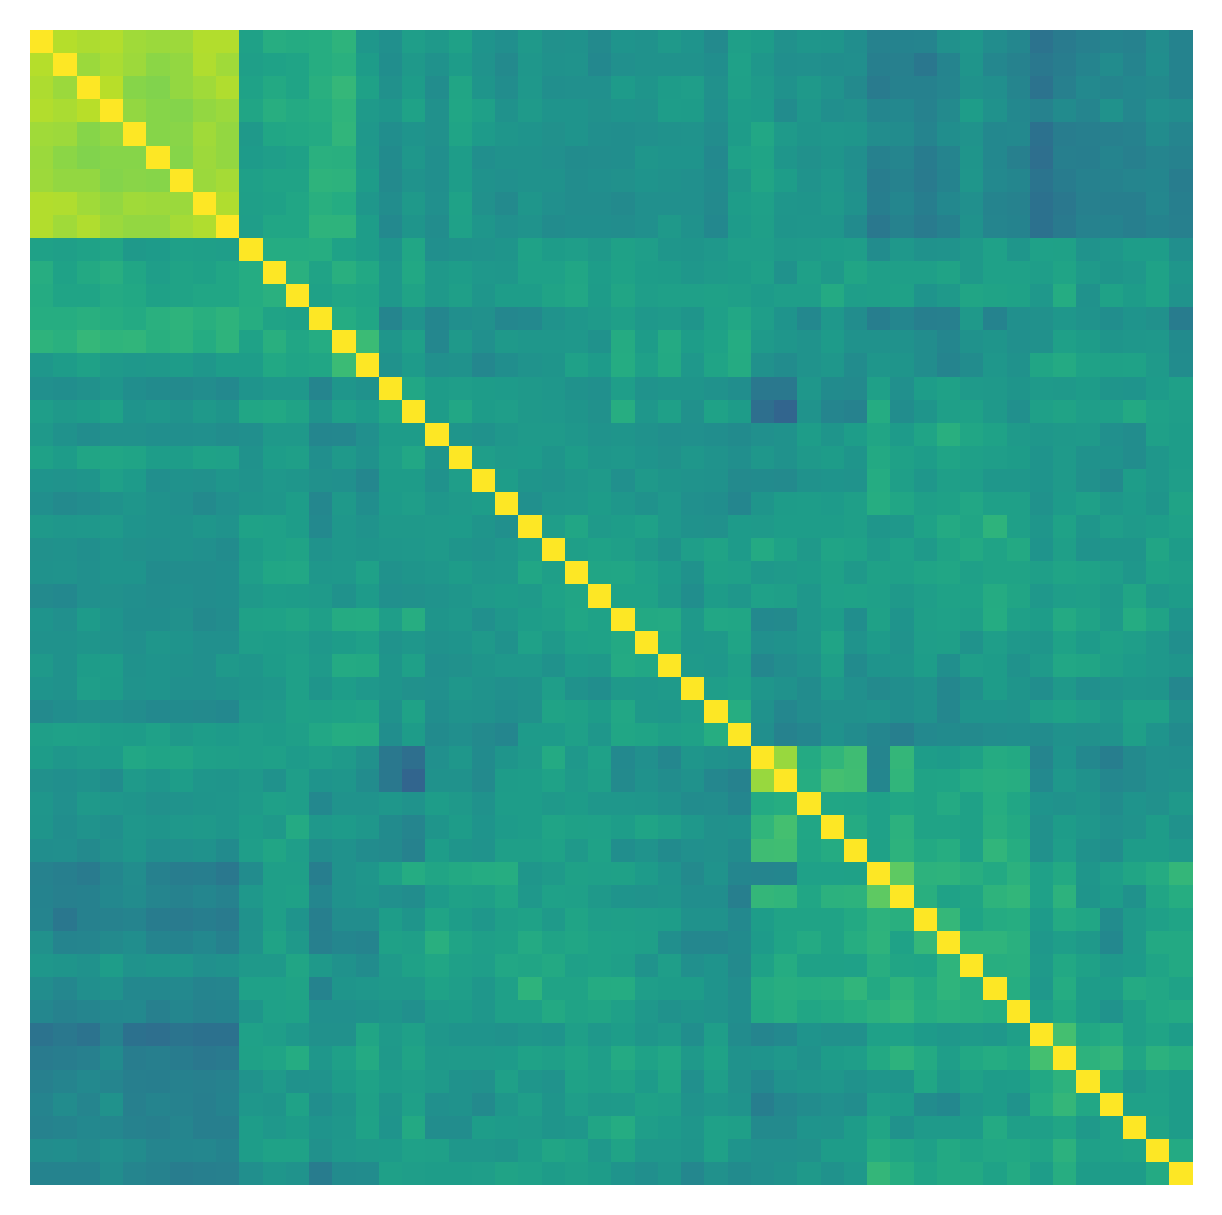

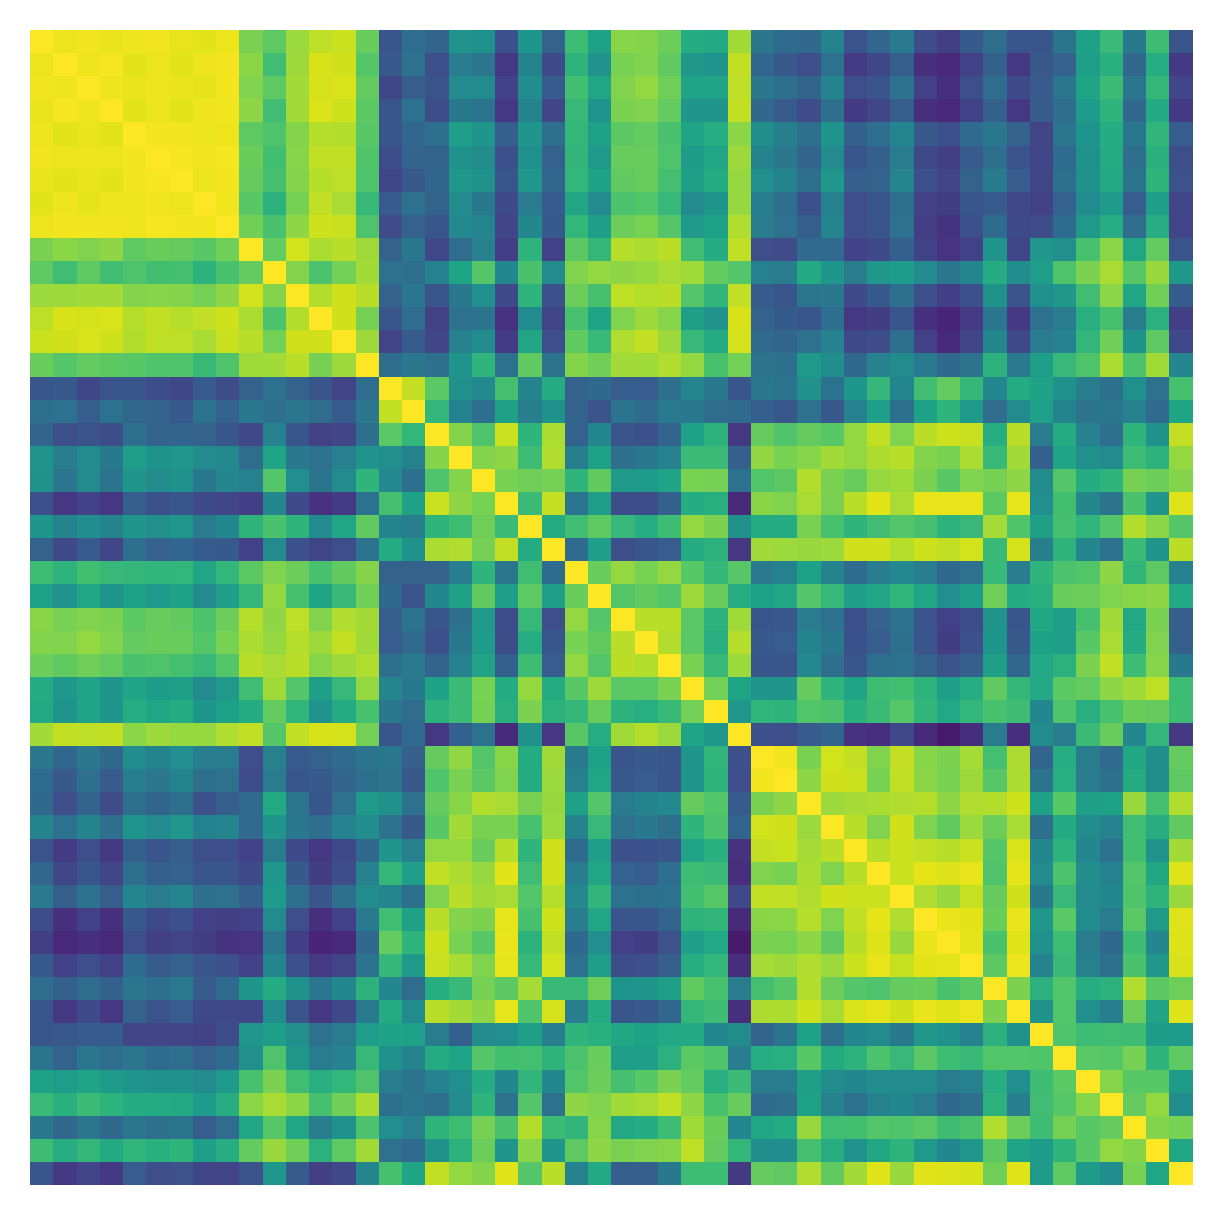

In [19]:
#plot heatmap of top 50 genes ranked by mean
def plot_heatmap(expression_gt, matched_spot_expression_pred, top_k=50):
    #take mean of expression
    mean = np.mean(expression_gt, axis=1)
    #take ind of top 100
    ind = np.argpartition(mean, -top_k)[-top_k:]

    # Compute the correlation matrix
    corr_matrix = np.corrcoef(expression_gt[ind,:])
    dendrogram = hierarchy.dendrogram(hierarchy.linkage(corr_matrix, method='ward'), no_plot=True)
    cluster_idx = dendrogram['leaves']

    corr_matrix = np.corrcoef(matched_spot_expression_pred[ind,:])
    corr_matrix = corr_matrix[cluster_idx, :]
    corr_matrix = corr_matrix[:, cluster_idx]

    # Reorder the correlation matrix and plot the heatmap
    plt.figure(dpi=300, figsize=(5,5))
    sns.heatmap(corr_matrix, cmap='viridis', xticklabels=False, yticklabels=False, cbar= False, vmin=-1, vmax=1)

plot_heatmap(expression_gt, expression_gt, top_k=50)
plot_heatmap(expression_gt, matched_spot_expression_pred_1, top_k=50)
# plot_heatmap(expression_gt, matched_spot_expression_pred_2, top_k=50)
# plot_heatmap(expression_gt, matched_spot_expression_pred_3, top_k=50)


